In [1]:
import matplotlib.pyplot as plt
import spacy
from sklearn.decomposition import PCA
import numpy as np

nlp = spacy.load("en_core_web_md")

c:\Users\bisha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
words = ["wonderful", "horrible", "apple", "banana", "orange", "watermelon", "dog", "cat"]
words_vectors = np.vstack([nlp.vocab.vectors[nlp.vocab.strings[w]] for w in words])

In [4]:
words_vectors

array([[ 0.66657 , -1.5147  , -2.99    , ...,  3.7106  , -5.5769  ,
         0.13872 ],
       [ 0.70032 , -1.9993  , -0.058583, ...,  3.2404  , -0.40047 ,
         0.38821 ],
       [-1.0084  , -2.0308  , -0.64185 , ...,  0.59301 ,  0.99132 ,
        -0.82037 ],
       ...,
       [ 0.24011 , -2.4556  , -1.5484  , ..., -1.161   , -0.10306 ,
         0.12286 ],
       [ 1.233   ,  4.2963  , -7.9738  , ..., 11.174   , -8.0568  ,
         5.7985  ],
       [ 3.7032  ,  4.1982  , -5.0002  , ...,  6.0303  , -6.9664  ,
         3.1445  ]], dtype=float32)

In [8]:
pca = PCA(n_components=2)
word_vectors_transformed = pca.fit_transform(words_vectors)

In [9]:
word_vectors_transformed

array([[-13.53576  ,  22.203266 ],
       [-11.733269 ,  23.981333 ],
       [-17.829933 , -17.512646 ],
       [-15.667821 ,  -7.332808 ],
       [-19.457375 , -13.099239 ],
       [-17.269348 ,  -4.749803 ],
       [ 54.33016  ,  -2.9209447],
       [ 41.163353 ,  -0.5691579]], dtype=float32)

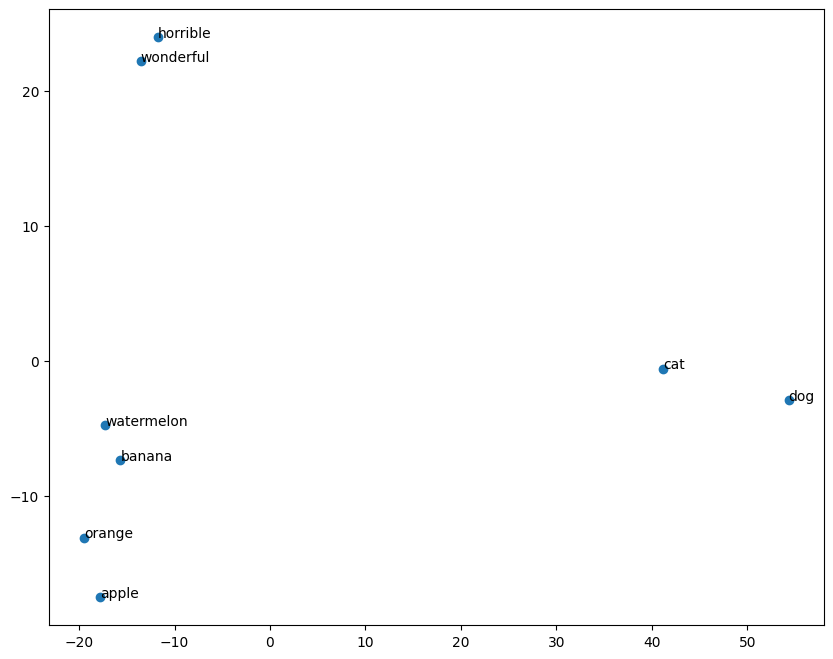

In [10]:
plt.figure(figsize=(10, 8))
plt.scatter(word_vectors_transformed[:,0], word_vectors_transformed[:,1])

for word, coord in zip(words, word_vectors_transformed):
    x,y = coord
    plt.text(x,y, word, size=10)
plt.show()

In [14]:
# finding syntactically similar words

word = "covid"
most_similar_words = nlp.vocab.vectors.most_similar(
    np.asarray([nlp.vocab.vectors[nlp.vocab.strings[word]]]),
    n=5
)

words = [nlp.vocab.strings[w] for w in most_similar_words[0][0]]
print(words)

['Covi', 'CoVid', 'Covici', 'COIVD-19', 'coronado']


In [ ]:
nlp.vocab.strings["human"] # this will give the index of the word "human" in the vocabulary
nlp.vocab.vectors[nlp.vocab.strings["human"]] # this will give the vector representation of the word "human" 

5674190450704392893